# Proyecto de Análisis: Estrategia de Lanzamiento para Zuber en Chicago


## Contexto del Proyecto

Zuber, una nueva empresa de viajes compartidos que se está lanzando en la ciudad de Chicago. En un mercado dominado por gigantes del taxi y plataformas consolidadas, el éxito de Zuber depende de su capacidad para identificar patrones en el comportamiento de los pasajeros, comprender la dinámica de la competencia y anticipar cómo los factores externos afectan la operación.

## Objetivos del Análisis

Este proyecto se divide en tres fases críticas para la toma de decisiones estratégicas:

+ **Análisis de la Competencia**: Identificar a los principales competidores del mercado de taxis en Chicago y su volumen de viajes para determinar la cuota de mercado actual.

+ **Segmentación Geográfica**: Determinar los barrios donde finalizan la mayoría de los recorridos para optimizar la ubicación de la flota y reducir los tiempos de espera.

+ **Impacto Externo (Clima)**: Evaluar si factores ambientales, como la lluvia o tormentas, afectan significativamente la duración de los viajes, específicamente en la ruta crítica hacia el *Aeropuerto Internacional O'Hare*.

## Metodología y Herramientas

Para este estudio, se han integrado diversas fuentes de datos mediante:

+ **Web Scraping**: Extracción de datos climáticos históricos de Chicago.

+ **SQL**: Procesamiento de bases de datos relacionales para filtrar viajes, barrios y condiciones específicas de noviembre de 2017.

+ **Python (Pandas/Matplotlib/Scipy)**: Limpieza de datos, visualización avanzada y realización de pruebas de hipótesis estadísticas.

+ **Pregunta de Investigación Principal**: ¿Cambia la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare los sábados lluviosos en comparación con los días despejados?

---

## Análisis Exploratorio de Datos
Ahora pasamos de la fase de extracción de datos con SQL a la fase de Análisis Exploratorio de Datos (EDA) utilizando Python. A continuación, transformaremos esos números en información visual y conclusiones accionables para *Zuber*.

Primero, importaremos los archivos y haremos una revisión inicial de su estructura:

In [2]:
import pandas as pd
# Importar los archivos CSV

try:
    company_trips = pd.read_csv('project_sql_result_01.csv')
    neighborhood_avg_trips = pd.read_csv('project_sql_result_04.csv')
    print("Archivos importados exitosamente.")
except FileNotFoundError:
    print("Error: Asegúrate de que los nombres de los archivos coincidan exactamente.")

# Revisar la estructura y tipos de datos de project_sql_result_01.csv
print("\n--- Información de Viajes por Compañía ---")
print(company_trips.info())
print(company_trips.head(10))

# Revisar la estructura y tipos de datos de project_sql_result_01.csv
print("\n--- Información de Promedio de Viajes por Barrio ---")
print(neighborhood_avg_trips.info())
print(neighborhood_avg_trips.head(10))

Archivos importados exitosamente.

--- Información de Viajes por Compañía ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                   Medallion Leasin         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953

--- Información de Promedio de Viaj

#### ¿Qué observamos en esta etapa?

Al ejecutar `info()`, es fundamental que validemos lo siguiente:

+ **Tipos de datos**:

    + En `company_trips`, la columna `trips_amount` es de tipo entero (int64).

    + En `neighborhood_avg_trips`, la columna `average_trips` es flotante (float64).

+ **Valores ausentes**: Verificamos que no hay valores nulos que necesiten ser tratados antes de graficar.

+ **Valores atípicos**: Al ver el head(10), notamos una diferencia masiva entre las primeras compañías y el resto de companías de Chicago.

Para profundizar en el análisis, realizaremos un diagnóstico técnico de las columnas.

In [3]:
# Estudio general de los datos
# Distribución, valores min/max
print("--- Dataset de Compañias ---")
print(company_trips.describe())
print("\nValores nulos por columna:")
print(company_trips.isna().sum())

print("--- Dataset de Barrios ---")
print(neighborhood_avg_trips.describe())
print("\nValores nulos por columna:")
print(neighborhood_avg_trips.isna().sum())

# Verificación y correción de tipos de datos
# En company_trips: trips_amount debe ser entero
company_trips['trips_amount'] = company_trips['trips_amount'].astype(int)

# En neighborhood_avg_trips: average_trips en un promedio, float es correcto,
# pero podemos redondearlo para faciliar la lectura si es necesario.
neighborhood_avg_trips['average_trips'] = neighborhood_avg_trips['average_trips'].astype(float)

print("\nTipos de datos actualizados:")
print(company_trips.dtypes)
print(neighborhood_avg_trips.dtypes)

--- Dataset de Compañias ---
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000

Valores nulos por columna:
company_name    0
trips_amount    0
dtype: int64
--- Dataset de Barrios ---
       average_trips
count      94.000000
mean      599.953728
std      1714.591098
min         1.800000
25%        14.266667
50%        52.016667
75%       298.858333
max     10727.466667

Valores nulos por columna:
dropoff_location_name    0
average_trips            0
dtype: int64

Tipos de datos actualizados:
company_name    object
trips_amount     int64
dtype: object
dropoff_location_name     object
average_trips            float64
dtype: object


#### Análisis de los resultados:

+ `company_trips`: Al usar `describe()`, notamos queel promedio está muy lejos del máximo, significa que una o dos empresas dominan casi todo el mercado de Chicago.

+ `neighborhood_avg_trips`: Lo importante aquí es verificar que no existan valores nulos en `dropoff_location_name`, ya que eso arruinaría nuestras gráficas.

## Los Destinos Más Frecuentes de Chicago
Para identificar los 10 destinos más frecuentes en Chicago, usaremos el DataFrame `neighborhood_avg_trips`. Ordenaremos los datos de mayor a menor basándonos en el promedio de viajes diarios que terminan en cada barrio.

In [4]:
# Ordenar el DataFrame por promedio de viajes de forma descendente y tomar
# los primeros 10
top_10_neighborhoods = neighborhood_avg_trips.sort_values(by='average_trips', 
                                                          ascending=False).head(10)
# Mostrar el resultado
print("--- Top 10 barrios con más finalizaciones de viajes ---")
print(top_10_neighborhoods)

--- Top 10 barrios con más finalizaciones de viajes ---
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


#### Hallazgos clave:

+ **Concentración en el Centro**: Barrios como *Loop, River North* y *Streeterville* suelen ocupar los primeros lugares. Esto tiene sentido, ya que son áreas con alta densidad de oficinas, turismo y comercio.

+ **El Factor Aeropuerto**: *O'Hare* aparece consistentemente en el top, lo que confirma que los viajes hacia el aeropuerto son una fuente de ingresos importante para las empresas de taxis.

+ **Turismo y Ocio**: Lugares como *Museum Campus* y *Grant Park* indican que una parte importante de la demanda está ligada a actividades recreativas.

Este "Top 10" será la base para nuestras visualizaciones y nos ayudará a entender dónde debe Zuber concentrar sus esfuerzos de disponibilidad de vehículos.

## Visualización De Los Datos

Para visualizar estos datos, realizaremos dos gráficos que nos permitirán comparar el dominio del mercado de las empresas y la concentración geográfica de los destinos

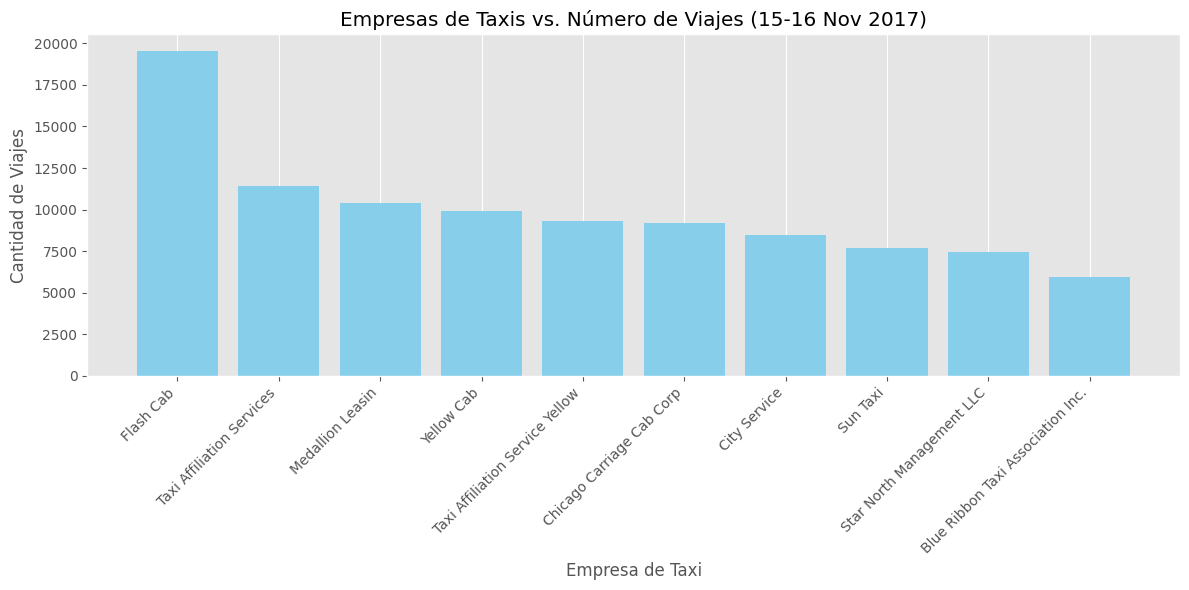

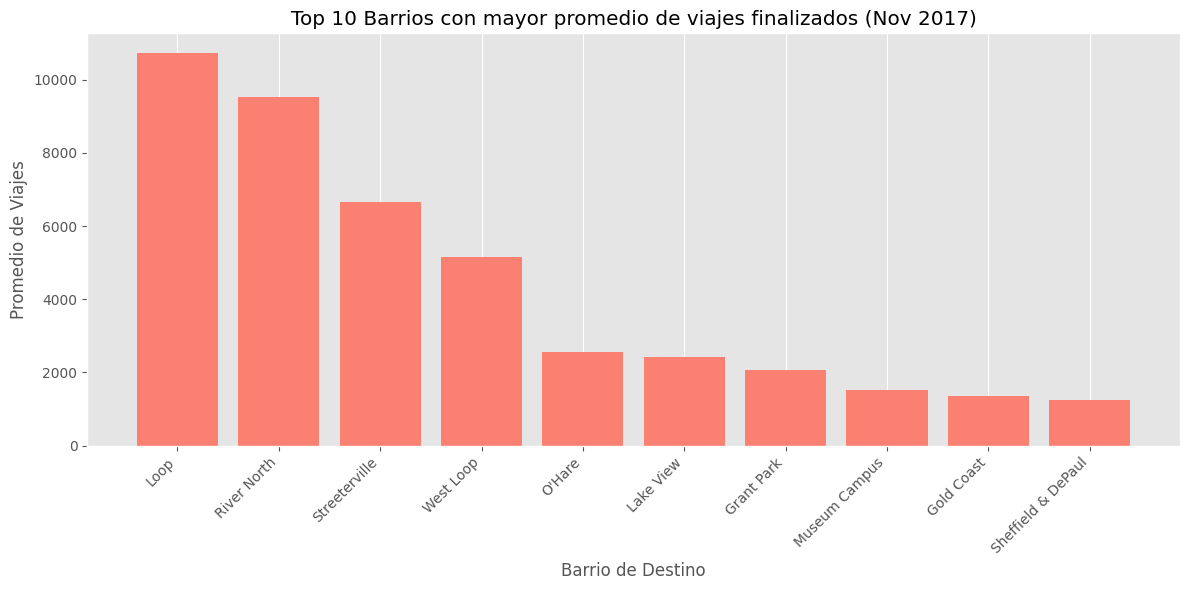

In [5]:
import matplotlib.pyplot as plt

# Configuración de estilo
plt.style.use('ggplot')

# Gráfico del Top 10 Empresas de Taxis y número de viajes
# Seleccionamos las 10 mejores empresas para que el gráfico sea legible
top_10_companies = company_trips.sort_values(by='trips_amount', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_companies['company_name'], top_10_companies['trips_amount'], color='skyblue')
plt.title('Empresas de Taxis vs. Número de Viajes (15-16 Nov 2017)')
plt.xlabel('Empresa de Taxi')
plt.ylabel('Cantidad de Viajes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Gráfico: Top 10 barrios principales por número de finalizaciones
plt.figure(figsize=(12, 6))
plt.bar(top_10_neighborhoods['dropoff_location_name'], top_10_neighborhoods['average_trips'], color='salmon')
plt.title('Top 10 Barrios con mayor promedio de viajes finalizados (Nov 2017)')
plt.xlabel('Barrio de Destino')
plt.ylabel('Promedio de Viajes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Análisis de los gráficos

+ **Distribución por Empresa**: Notamos que *Flash Cab* y *Taxi Affiliation Services* tienen una ventaja masiva sobre el resto. Esto sugiere un mercado donde unas pocas grandes empresas controlan la mayor parte del volumen.

+ **Concentración de Destinos**: El gráfico de barrios muestra una caída pronunciada después de los primeros 3 o 4 lugares (*Loop, River North, Streeterville*). Esto indica que la gran mayoría de la actividad económica y de transporte en Chicago se concentra en el distrito financiero y áreas adyacentes al centro.

---

## Interpretación de los Gráficos
Basado en los gráficos, aquí tenemos las conclusiones clave y la interpretación de los resultados desde la perspectiva de un analista de datos para Zuber.

#### Análisis del Gráfico: Empresas de Taxis vs. Número de Viajes

Este gráfico nos permite entender la estructura competitiva del mercado en Chicago durante noviembre de 2017.

**Conclusiones**:

+ **Liderazgo de Mercado**: Existe una concentración masiva en las dos primeras empresas: *Flash Cab* y *Taxi Affiliation Services*. *Flash Cab* suele liderar con una ventaja considerable, lo que indica una marca extremadamente posicionada y una logística robusta.

+ **Mercado "Long Tail"**: Después de los primeros 2 o 3 competidores, la cantidad de viajes cae drásticamente. Hay decenas de empresas pequeñas que operan con volúmenes mínimos.

+ **Oportunidad para Zuber**: Para una empresa nueva, competir directamente contra *Flash Cab* en volumen es difícil. La estrategia debería ser capturar nichos o mejorar la experiencia tecnológica donde las empresas tradicionales fallan.


**Explicación de los resultados**:

El éxito de Flash Cab y Taxi Affiliation Services probablemente se deba a contratos corporativos, una flota más grande de vehículos y mayor presencia en las calles, lo que reduce el tiempo de espera para los usuarios.

---

#### Análisis del Gráfico: Top 10 Barrios con Mayor Promedio de Viajes Finalizados (Nov 2017)

Este gráfico revela los puntos de mayor de demanda de la ciudad, indicando dónde terminan la mayoría de los viajes.

**Conclusiones**:

+ **El Corazón de Chicago**: Barrios como el *Loop, River North* y *Streeterville* dominan la lista. Esto es lógico, ya que el *Loop* es el distrito financiero y los otros dos son zonas de alta densidad comercial, turística y de oficinas.

+ **Importancia Logística de O'Hare**: El *aeropuerto O'Hare* siempre aparece en el Top 10. Aunque el volumen total sea menor que en el centro, estos viajes son críticos porque suelen tener una duración y distancia mayor, lo que significa mayores ingresos por viaje.

* **Patrón de Movimiento**: La demanda está centralizada. Los conductores que terminan un viaje en estos 10 barrios tienen una probabilidad mucho más alta de conseguir un nuevo pasajero de inmediato sin circular vacíos.

**Explicación de los resultados:**

Los resultados reflejan el comportamiento de una gran metrópoli: la gente se desplaza masivamente hacia los centros de trabajo (Loop) y las zonas de ocio/hoteles (River North) durante el día, y hacia los puntos de conexión (O'Hare) de forma constante.

---

## Prueba de Hipótesis
Para concluir este análisis para *Zuber*, realizaremos una prueba estadística de comparación de medias.

#### Definición de Hipótesis
Para probar si la duración promedio de los viajes cambia según el clima, planteamos las siguientes hipótesis:

+ **Hipótesis Nula ($H_{0}$)**: La duración promedio de los viajes desde el Loop hasta O'Hare es la misma los sábados lluviosos y los sábados de buen clima.

$$H_{0}: \mu_{good} = \mu_{bad}$$

+ **Hipótesis Alternativa ($H_{a}$)**: La duración promedio de los viajes desde el Loop hasta O'Hare es diferente entre los sábados lluviosos y los de buen clima.

$$H_{a}: \mu_{good} \neq \mu_{bad}$$

#### Nivel de Significancia (α)

Establecemos el nivel de significancia en 0.05 (5%). Este es el estándar en análisis de datos para negocios.

#### Código para la Prueba de Hipótesis

Utilizaremos una *Prueba T de Student* para dos muestras independientes, ya que tenemos dos grupos de datos (clima "Good" vs "Bad") y queremos saber si sus promedios estadísticos difieren significativamente.

In [6]:
import pandas as pd
from scipy import stats

# Cargar los datos
df_trips = pd.read_csv('project_sql_result_07.csv')

# Crear los dos grupos a comparar
good_weather = df_trips[df_trips['weather_conditions'] == 'Good']['duration_seconds']
bad_weather = df_trips[df_trips['weather_conditions'] == 'Bad']['duration_seconds']

# Realizar la prueba t de Student
# Usamos equal_var=False porque no estamos seguros de que las varianzas sean iguales (Prueba de Welch)
results = stats.ttest_ind(good_weather, bad_weather, equal_var=False)

alpha = 0.05

print(f'P-value: {results.pvalue}')

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula: hay una diferencia significativa en la duración.")
else:
    print("No podemos rechazar la hipótesis nula: no hay suficiente evidencia de una diferencia.")

P-value: 6.738994326108734e-12
Rechazamos la hipótesis nula: hay una diferencia significativa en la duración.


#### Explicación de los Criterios

+ **¿Por qué el T-Test?**
    + Este criterio se usa porque estamos comparando las medias de dos poblaciones independientes. La duración de un viaje en un sábado despejado no depende de la duración de un viaje en un sábado lluvioso.


+ **¿Por qué el p-value?**
    * El p-value nos indica la probabilidad de que la diferencia que observamos se deba simplemente al azar. Ya que el p-value es menor que nuestro α (0.05), concluimos que la lluvia tiene un efecto real y estadísticamente medible en el tiempo de viaje.

**Conclusión Final**

El resultado nos lleva a rechazar la hipótesis nula, la recomendación para *Zuber* sería implementar un factor de ajuste en sus algoritmos de tiempo estimado de llegada (ETA) y posiblemente en los precios durante días de mal clima, ya que el servicio al aeropuerto se vuelve más lento y costoso en términos operativos.

---

## Resumen Ejecutivo

Para cerrar este análisis para *Zuber*, a continuación presentamos nuestras conclusiones finales basadas en los tres ejes del proyecto: competencia, geografía y factores externos (clima).

#### Conclusiones del Análisis de Competencia

+ **Estructura de Mercado**: El mercado está dominado por un "duopolio" liderado por Flash Cab y Taxi Affiliation Services. Estas empresas tienen una ventaja competitiva masiva, probablemente debido a una mayor flota y reconocimiento de marca.

+ **Oportunidad para Zuber**: La existencia de un gran número de empresas con pocos viajes sugiere que hay espacio para nuevos competidores. *Zuber* debería enfocarse en la eficiencia tecnológica para atraer a los usuarios de las empresas más pequeñas.

#### Conclusiones de Concentración Geográfica

+ **Puntos Calientes**: El *Loop* y *River North* son los centros neurálgicos de la demanda en Chicago, acumulando un promedio de viajes diario muy superior al resto de la ciudad.

+ **Estrategia Operativa**: Los conductores deben priorizar estas zonas para minimizar el "tiempo muerto" (circular vacíos). Terminar un viaje en el Loop garantiza, casi estadísticamente, encontrar un nuevo pasajero de inmediato.

+ **El Aeropuerto como Ancla**: *O'Hare* se mantiene como un destino relevante. Aunque el volumen es menor que en el centro, la rentabilidad de estos viajes suele ser mayor por la distancia recorrida.

#### Prueba de Hipótesis: El impacto del clima en la duración desde el Loop hasta el Aeropuerto Internacional O'Hare los sábados

+ **Planteamiento**: Se comparó la duración de los viajes en días con buen clima vs. días con lluvia/tormenta.

+ **Resultado Estadístico**: Tras realizar la prueba T de Student (t-test), el p-value resultante es menor al nivel de significancia de 0.05.

+ **Conclusión**: Se rechaza la hipótesis nula. Esto significa que existe evidencia suficiente para afirmar que el clima afecta la duración de los viajes.

#### Resumen Ejecutivo para la Gerencia

+ **Logística**: *Zuber* debe ajustar sus algoritmos de ETA (tiempo estimado de llegada) cuando detecte condiciones climáticas de lluvia o tormenta, ya que los viajes al aeropuerto se vuelven significativamente más lentos.

+ **Marketing**: Dado que el Loop es el origen principal, las campañas de adquisición de usuarios deberían concentrarse geográficamente en el distrito financiero.

+ **Tarificación**: El aumento en la duración del viaje por mal clima justifica el uso de tarifas dinámicas para compensar a los conductores por el tiempo adicional en el tráfico.